# `pottslab` — release smoke test

Exercises every public 1-D and 2-D Potts solver on small synthetic inputs to verify a release is functional. Useful as both:

- A post-publish check after `pip install pottslab`.
- A first-time-user introduction to the API.

Each section is self-contained and ends with a small assertion or visual check. Run-all should complete in a few seconds on any machine.

## 1. Install and import

Uncomment the install line if `pottslab` isn't on the active Python.

In [1]:
# %pip install --upgrade pottslab matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import pottslab as pl

rng = np.random.default_rng(0)


### Verify the Rust extension is loaded (not the pure-Python fallback)

If the Rust core isn't available, `pottslab` silently falls back to a pure-Python implementation that's **orders of magnitude slower**. The smoke test should fail loudly when that happens — otherwise a release with a broken wheel would silently pass.

In [2]:
import pottslab._core as _core
print('Rust core loaded from:', _core.__file__)
assert '_core_py' not in _core.__name__, 'pure-Python fallback in use; install a wheel'
assert 'site-packages' in _core.__file__, (
    f'pottslab imported from local source, not from a wheel: {_core.__file__}'
)

Rust core loaded from: e:\University\Year2\Term3\HCI\General\.venv\Lib\site-packages\pottslab\_core.cp311-win_amd64.pyd


## 2. 1-D L2-Potts — clean step signal

L2 Potts solves

$$\min_u \; \gamma \, \| Du \|_0 \; + \; \| u - f \|_2^2$$

via dynamic programming (O(n²)). Here `f` has two clean segments and one jump; with `gamma` smaller than the cost of merging them, we recover the original.

jumps recovered: 1
max |u - f_clean|: 0.0


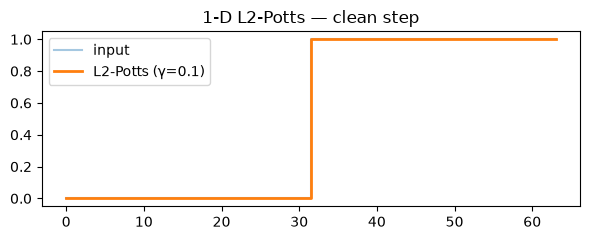

In [3]:
n = 64
f_clean = np.concatenate([np.zeros(n // 2), np.ones(n // 2)])
u = pl.min_l2_potts(f_clean, gamma=0.1)

print('jumps recovered:', pl.count_jumps(u))
print('max |u - f_clean|:', np.max(np.abs(u - f_clean)))

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.step(np.arange(n), f_clean, where='mid', alpha=0.4, label='input')
ax.step(np.arange(n), u, where='mid', linewidth=2, label='L2-Potts (γ=0.1)')
ax.set_title('1-D L2-Potts — clean step')
ax.legend(); plt.tight_layout(); plt.show()

## 3. 1-D L2-Potts — noisy signal

Three segments + Gaussian noise. The right `gamma` recovers all three jumps; too small leaves noise, too large collapses segments.

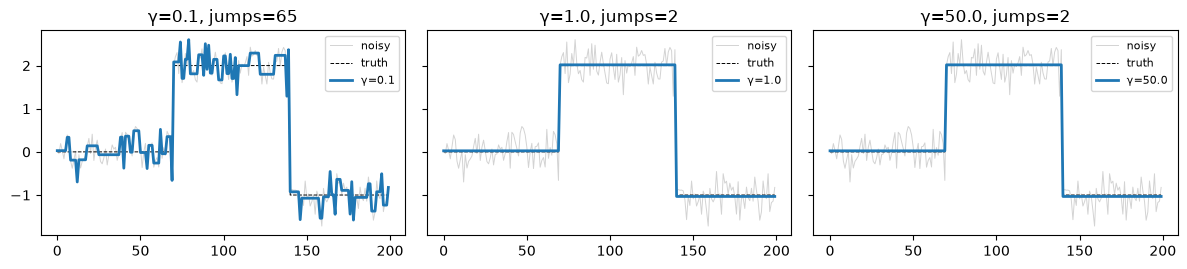

In [4]:
n = 200
truth = np.concatenate([np.zeros(70), 2 * np.ones(70), -1 * np.ones(60)])
f_noisy = truth + rng.normal(0, 0.3, size=n)

fig, axes = plt.subplots(1, 3, figsize=(12, 2.8), sharey=True)
for ax, gamma in zip(axes, [0.1, 1.0, 50.0]):
    u = pl.min_l2_potts(f_noisy, gamma=gamma)
    ax.plot(f_noisy, color='lightgray', linewidth=0.7, label='noisy')
    ax.plot(truth, '--', color='black', linewidth=0.7, label='truth')
    ax.plot(u, color='C0', linewidth=2, label=f'γ={gamma}')
    ax.set_title(f'γ={gamma}, jumps={pl.count_jumps(u)}')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 4. 1-D L1-Potts — robust to outliers

L1 Potts solves

$$\min_u \; \gamma \, \| Du \|_0 \; + \; \| u - f \|_1$$

and is robust to heavy-tailed noise / sparse outliers. We sprinkle 5% spike outliers onto the noisy signal and compare L1 vs L2 reconstructions.

`min_l1_potts` returns a tuple `(u, dataError, nJumps, energy)` — only `u` is needed for plotting.

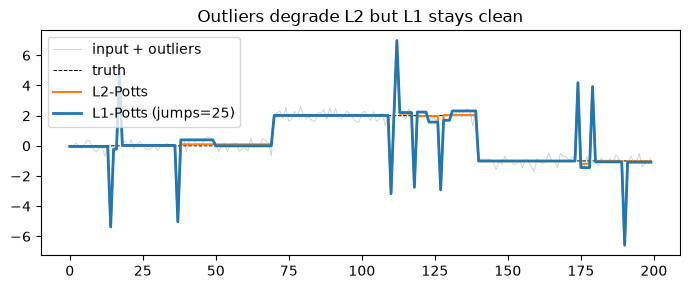

In [5]:
f_outliers = f_noisy.copy()
n_spikes = max(1, int(0.05 * len(f_outliers)))
spike_idx = rng.choice(len(f_outliers), size=n_spikes, replace=False)
f_outliers[spike_idx] += rng.choice([-5, 5], size=n_spikes)

u_l2 = pl.min_l2_potts(f_outliers, gamma=1.0)
u_l1, _, n_jumps_l1, _ = pl.min_l1_potts(f_outliers, gamma=1.0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(f_outliers, color='lightgray', linewidth=0.7, label='input + outliers')
ax.plot(truth, '--', color='black', linewidth=0.7, label='truth')
ax.plot(u_l2, color='C1', linewidth=1.5, label='L2-Potts')
ax.plot(u_l1, color='C0', linewidth=2, label=f'L1-Potts (jumps={n_jumps_l1})')
ax.legend(); ax.set_title('Outliers degrade L2 but L1 stays clean')
plt.tight_layout(); plt.show()

## 5. 2-D L2-Potts — image segmentation

`min_l2_potts_2d` uses ADMM to reduce the 2-D problem to many 1-D Potts solves run in parallel. Here we segment a synthetic image with a few constant regions plus noise. Output values should snap to a small set of levels.

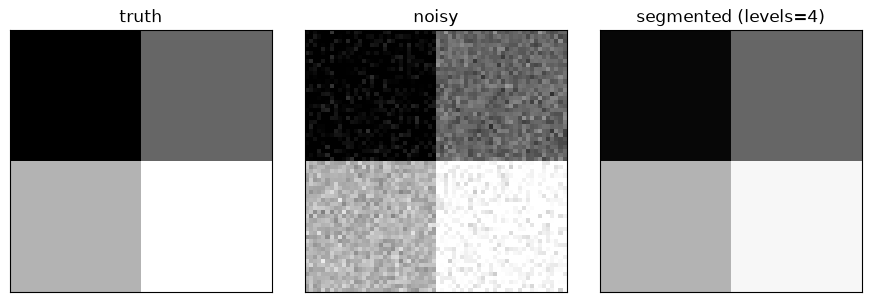

In [6]:
H, W = 64, 64
img_truth = np.zeros((H, W))
img_truth[:32, :32] = 0.0
img_truth[:32, 32:] = 0.4
img_truth[32:, :32] = 0.7
img_truth[32:, 32:] = 1.0
img_noisy = np.clip(img_truth + rng.normal(0, 0.07, size=(H, W)), 0, 1)

img_seg = pl.min_l2_potts_2d(img_noisy, gamma=0.5, isotropic=True)
n_levels = len(np.unique(img_seg))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, im, title in zip(axes,
                          [img_truth, img_noisy, img_seg],
                          ['truth', 'noisy', f'segmented (levels={n_levels})']):
    ax.imshow(im, vmin=0, vmax=1, cmap='gray')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

assert n_levels >= 4, 'expected ≥ 4 segment levels'

## 6. 2-D L2-Potts — RGB image

The 2-D solver works on multi-channel images too: pass shape `(H, W, C)` and `gamma` is shared across channels (joint segmentation).

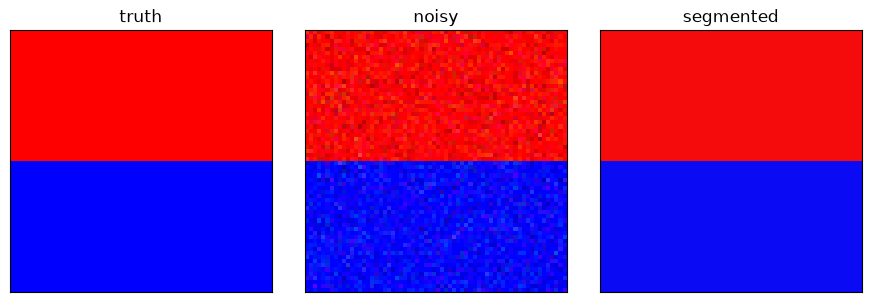

In [7]:
rgb_truth = np.zeros((H, W, 3))
rgb_truth[:H // 2, :, 0] = 1.0  # top half red
rgb_truth[H // 2:, :, 2] = 1.0  # bottom half blue
rgb_noisy = np.clip(rgb_truth + rng.normal(0, 0.1, size=rgb_truth.shape), 0, 1)
rgb_seg = pl.min_l2_potts_2d(rgb_noisy, gamma=0.8)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, im, title in zip(axes, [rgb_truth, rgb_noisy, rgb_seg],
                          ['truth', 'noisy', 'segmented']):
    ax.imshow(im); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Summary

If the cells above all rendered, the release is good for the basic 1-D and 2-D Potts solvers. The other public entry points (`min_l{1,2}_ipotts`, `min_l{1,2}_spars`, `min_l{1,2}_tikhonov`) are not exercised here but follow the same call style — see [README_PYTHON.md](../README_PYTHON.md) for a deeper tour.

In [8]:
import importlib.metadata

version = importlib.metadata.version('pottslab')
print(f'pottslab {version} — smoke test OK')

pottslab 1.0.1 — smoke test OK
